# Adding a New Potential in Python

galpy makes it straightforward to add new gravitational potentials.
Once implemented, a new potential automatically works with all of galpy's
orbit integration, action-angle, and distribution function machinery.

The steps are:

1. Create a class that inherits from `galpy.potential.Potential` for conservative forces or `galpy.potential.DissipativeForce` for dissipative forces (see [below](#Adding-dissipative-forces-to-the-galpy-framework))
2. Implement `__init__` calling `Potential.__init__` or `DissipativeForce.__init__` with appropriate parameters
3. Implement `_evaluate(self, R, z, phi=0., t=0.)` for the potential value (not for dissipative forces)
4. Implement `_Rforce(self, R, z, phi=0., t=0.)` for the radial force
5. Implement `_zforce(self, R, z, phi=0., t=0.)` for the vertical force
6. Implement `_phitorque(self, R, z, phi=0., t=0.)` for the azimuthal torque (if non-axisymmetric)
7. Optionally implement `_dens`, `_R2deriv`, `_z2deriv`, `_Rzderiv`, etc.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import Potential
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Example: a custom softened power-law potential

Let's implement a softened isothermal-like potential of the form:

$$\Phi(R, z) = \frac{1}{2}\,v_0^2\,\ln(R^2 + z^2 + d^2)$$

where $v_0$ sets the circular velocity scale and $d$ is a softening length.
This is similar to the logarithmic potential but implemented from scratch
to illustrate the process.

In [2]:
class SoftenedLogPotential(Potential):
    """A softened logarithmic potential: Phi = 0.5 * v0^2 * ln(R^2 + z^2 + d^2)."""

    def __init__(self, amp=1.0, v0=1.0, d=0.1, ro=None, vo=None):
        """
        Initialize the potential.

        Parameters
        ----------
        amp : float
            Overall amplitude.
        v0 : float
            Velocity scale (in natural units).
        d : float
            Softening length (in natural units).
        ro, vo : float, optional
            Unit conversion parameters.
        """
        Potential.__init__(self, amp=amp, ro=ro, vo=vo)
        self._v0 = v0
        self._d = d
        self._d2 = d**2.0

    def _evaluate(self, R, z, phi=0.0, t=0.0):
        return 0.5 * self._v0**2.0 * numpy.log(R**2.0 + z**2.0 + self._d2)

    def _Rforce(self, R, z, phi=0.0, t=0.0):
        return -(self._v0**2.0) * R / (R**2.0 + z**2.0 + self._d2)

    def _zforce(self, R, z, phi=0.0, t=0.0):
        return -(self._v0**2.0) * z / (R**2.0 + z**2.0 + self._d2)

## Using the new potential

Our new potential immediately works with galpy's plotting functions,
orbit integration, and other tools.

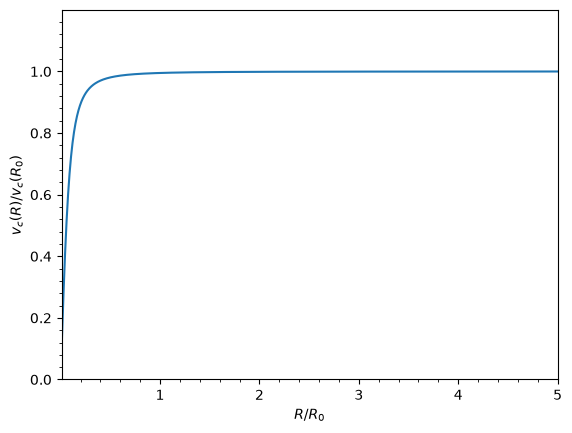

In [3]:
sp = SoftenedLogPotential(v0=1.0, d=0.1)
sp.plotRotcurve(Rrange=[0.01, 5.0], grid=1001);

## Orbit integration with the new potential

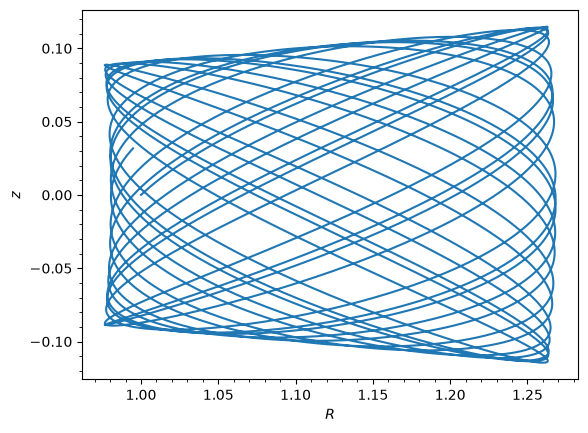

In [4]:
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.1])
ts = numpy.linspace(0, 100, 10000)
o.integrate(ts, sp)
o.plot();

Note the warning message about not being able to use C integration, because the new potential does not have a C implementation. This means that orbit integration will be slower than for built-in potentials, but it will still work correctly.

## Using normalize

The `normalize` keyword can be used to set the circular velocity at R=1 to a
desired value. We can call `normalize()` after initialization.

In [5]:
sp_norm = SoftenedLogPotential(v0=1.0, d=0.1)
sp_norm.normalize(1.0)
print("v_circ at R=1:", sp_norm.vcirc(1.0))

v_circ at R=1: 1.0


## Physical units with amp_units

To allow users to specify the amplitude of your potential in physical units
(e.g., solar masses or km/s), add an `amp_units` class attribute. For example,
for a potential whose amplitude has units of velocity squared:

```python
class MyPotential(Potential):
    amp_units = 'velocity2'
    ...
```

Valid options include `'mass'`, `'velocity2'`, `'density'`, and `'surfacedensity'`.
This enables the potential to accept astropy Quantity inputs for the amplitude.

See the galpy documentation on physical units for full details.

## Complete list of implementable methods

The following methods can be implemented in a custom potential class.
All methods receive `(self, R, z, phi=0., t=0.)` as arguments. The
return values should **not** include the `amp` factor -- galpy handles
multiplication by `amp` automatically.

**Core methods (recommended minimum):**

- `_evaluate` -- the potential value $\Phi(R, z, \phi, t)$ (without `amp`)
- `_Rforce` -- the radial force $-\partial\Phi/\partial R$
- `_zforce` -- the vertical force $-\partial\Phi/\partial z$

**Second derivatives:**

- `_R2deriv` -- $\partial^2\Phi/\partial R^2$
- `_z2deriv` -- $\partial^2\Phi/\partial z^2$
- `_Rzderiv` -- $\partial^2\Phi/\partial R\,\partial z$
- `_phi2deriv` -- $\partial^2\Phi/\partial\phi^2$
- `_Rphideriv` -- $\partial^2\Phi/\partial R\,\partial\phi$

**Other optional methods:**

- `_dens` -- the density $\rho(R, z, \phi, t)$ (galpy can compute this numerically via Poisson's equation, but an analytical form is faster and more accurate)
- `_mass` -- the enclosed mass
- `_phitorque` -- the azimuthal torque $-\partial\Phi/\partial\phi$ (required for non-axisymmetric potentials)

All of these should be implemented without the `amp` factor.

## Automatic numerical derivatives with NumericalPotentialDerivativesMixin

If you only want to implement `_evaluate`, `_Rforce`, and `_zforce` but still
need second derivatives, you can use
`NumericalPotentialDerivativesMixin`. This mixin automatically computes
`_R2deriv`, `_z2deriv`, `_Rzderiv`, `_phi2deriv`, and `_Rphideriv` numerically
from the forces.

To use it, inherit from both the mixin and `Potential`:

```python
from galpy.potential import NumericalPotentialDerivativesMixin

class MyPotential(NumericalPotentialDerivativesMixin, Potential):
    def __init__(self, amp=1., ro=None, vo=None):
        Potential.__init__(self, amp=amp, ro=ro, vo=vo)

    def _evaluate(self, R, z, phi=0., t=0.):
        ...

    def _Rforce(self, R, z, phi=0., t=0.):
        ...

    def _zforce(self, R, z, phi=0., t=0.):
        ...
```

The mixin must appear **before** `Potential` in the inheritance list so its
methods take precedence. The numerical derivatives are computed using finite
differences and are accurate enough for most purposes.

## Important class attributes

Several class attributes control how galpy interacts with your potential:

- `hasC = True` -- set this if you also provide a C implementation of the potential (for fast orbit integration). See the [Adding a New Potential in C](new_potential_c.rst) tutorial.
- `hasC_dxdv = True` -- set this if the C implementation also supports phase-space derivatives (for variational integration).
- `hasC_dens = True` -- set this if the C implementation includes a density function (required for dynamical friction in this potential).
- `isNonAxi = True` -- set this if the potential is non-axisymmetric (depends on $\phi$). This is `False` by default.
- `_dim = 3` -- the dimensionality of the potential. The default is 3; set to 2 for planar potentials or 1 for one-dimensional potentials.

These are set as class attributes or in `__init__`. For example:

```python
class MyNonAxiPotential(Potential):
    isNonAxi = True

    def __init__(self, amp=1., ro=None, vo=None):
        Potential.__init__(self, amp=amp, ro=ro, vo=vo)
        ...
```

## Adding wrapper potentials

galpy also supports *wrapper potentials* that modify or combine existing
potentials. If you want to create a potential that wraps another potential
(e.g., to make it time-dependent or to apply a spatial transformation),
inherit from `parentWrapperPotential`. This base class automatically
handles both 3D and 2D (planar) wrapping:

```python
from galpy.potential.WrapperPotential import parentWrapperPotential

class MyWrapperPotential(parentWrapperPotential):
    def __init__(self, amp=1., pot=None, ro=None, vo=None):
        parentWrapperPotential.__init__(self, amp=amp, pot=pot, ro=ro, vo=vo)
        ...
```

The wrapped potential is available as `self._pot` inside your methods. See
the existing wrapper potentials (e.g., `DehnenSmoothWrapperPotential`,
`SolidBodyRotationWrapperPotential`) in the galpy source for examples of
how to implement these.

## Adding dissipative forces to the galpy framework

Dissipative (velocity-dependent) forces are implemented similarly to
conservative potentials, but inherit from `galpy.potential.DissipativeForce`
instead of `galpy.potential.Potential`. The main differences are:

1. You only need to implement the **forces** (not `_evaluate`, since there is no potential energy for a dissipative force).
2. The force methods take an extra keyword argument `v=` that gives the current velocity in cylindrical coordinates as a list `[vR, vT, vz]`, because dissipative forces generally depend on the velocity.

The steps are:

1. Create a class that inherits from `DissipativeForce`.
2. In `__init__`, call `DissipativeForce.__init__(self, amp=amp, ro=ro, vo=vo, amp_units=...)` to set up the amplitude and unit system.
3. Implement the following force methods, each accepting `v=None` as a keyword:
   - `_Rforce(self, R, z, phi=0., t=0., v=None)` -- the radial force
   - `_phitorque(self, R, z, phi=0., t=0., v=None)` -- the azimuthal torque
   - `_zforce(self, R, z, phi=0., t=0., v=None)` -- the vertical force

The `v` argument is a list `[vR, vT, vz]` in cylindrical coordinates. As for
conservative potentials, the return values should **not** include the `amp`
factor.

The built-in `ChandrasekharDynamicalFrictionForce` provides a good template
to follow. There is currently no support for implementing dissipative forces
in C.

For a complete worked example of adding a custom velocity-dependent force --
implementing Schwarzschild precession to model the relativistic orbit of the
S2 star around Sgr A* -- see the
[Dissipative Forces](../potentials/dissipative.ipynb#Example:-Schwarzschild-precession-of-the-S2-orbit-around-Sgr-A*)
tutorial.